<a href="https://colab.research.google.com/github/yehiayaser/diabetes/blob/main/diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [22]:
df=pd.read_csv('/content/diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [23]:
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [24]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [25]:
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [26]:

df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [27]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)


In [28]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the first few rows of the scaled training data
print("Scaled Training Data (first 5 rows):")
display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

# Display the first few rows of the scaled testing data
print("\nScaled Testing Data (first 5 rows):")
display(pd.DataFrame(X_test_scaled, columns=X_test.columns).head())

Scaled Training Data (first 5 rows):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.526397,-1.151398,-3.752683,-1.322774,-0.701206,-4.135256,-0.490735,-1.035940
1,1.588046,-0.276643,0.680345,0.233505,-0.701206,-0.489169,2.415030,1.487101
2,-0.828460,0.566871,-1.265862,-0.090720,0.013448,-0.424522,0.549161,-0.948939
3,-1.130523,1.254179,-1.049617,-1.322774,-0.701206,-1.303720,-0.639291,2.792122
4,0.681856,0.410665,0.572222,1.076490,2.484601,1.838121,-0.686829,1.139095



Scaled Testing Data (first 5 rows):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.681856,-0.714020,-0.617127,0.817110,0.934749,0.260736,-0.116372,0.878091
1,-0.526397,-0.276643,0.301916,0.752265,-0.701206,0.480535,-0.954231,-1.035940
2,-0.526397,-0.401608,-0.292759,-1.322774,-0.701206,-0.153005,-0.924520,-1.035940
3,1.285983,-0.432849,0.572222,-1.322774,-0.701206,-0.954627,1.149329,0.095078
4,0.983919,0.473147,1.112835,-1.322774,-0.701206,-0.269369,-0.770021,1.487101


In [29]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=500,verbose=1)

# Train the model on the scaled training data
model.fit(X_train_scaled, y_train)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


LogisticRegression(max_iter=500, verbose=1)

In [30]:
from sklearn.metrics import classification_report

# Classification report for training data
y_train_pred = model.predict(X_train_scaled)
cr_train = classification_report(y_train, y_train_pred)
print("Classification Report for Training Data:")
print(cr_train)

# Classification report for test data
y_test_pred = model.predict(X_test_scaled)
cr_test = classification_report(y_test, y_test_pred)
print("\nClassification Report for Test Data:")
print(cr_test)

Classification Report for Training Data:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       401
           1       0.72      0.56      0.63       213

    accuracy                           0.77       614
   macro avg       0.75      0.72      0.73       614
weighted avg       0.76      0.77      0.76       614


Classification Report for Test Data:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [31]:
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Display the shapes of the original and resampled training sets
print("Shape of original X_train:", X_train_scaled.shape)
print("Shape of resampled X_train:", X_train_resampled.shape)
print("Shape of original y_train:", y_train.shape)
print("Shape of resampled y_train:", y_train_resampled.shape)

# Display the class distribution in the original and resampled training sets
print("\nClass distribution in original y_train:")
print(pd.Series(y_train).value_counts())

print("\nClass distribution in resampled y_train:")
print(pd.Series(y_train_resampled).value_counts())

Shape of original X_train: (614, 8)
Shape of resampled X_train: (802, 8)
Shape of original y_train: (614,)
Shape of resampled y_train: (802,)

Class distribution in original y_train:
Outcome
0    401
1    213
Name: count, dtype: int64

Class distribution in resampled y_train:
Outcome
0    401
1    401
Name: count, dtype: int64


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize a new Logistic Regression model
model_resampled = LogisticRegression()

# Train the model on the SMOTE-resampled training data
model_resampled.fit(X_train_resampled, y_train_resampled)

# Make predictions on the scaled testing data using the new model
y_pred_resampled = model_resampled.predict(X_test_scaled)

# Evaluate the new model
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
print(f"Accuracy (Resampled Data): {accuracy_resampled:.4f}")

print("\nClassification Report (Resampled Data):")
print(classification_report(y_test, y_pred_resampled))

print("\nConfusion Matrix (Resampled Data):")
print(confusion_matrix(y_test, y_pred_resampled))

Accuracy (Resampled Data): 0.7078

Classification Report (Resampled Data):
              precision    recall  f1-score   support

           0       0.82      0.70      0.75        99
           1       0.57      0.73      0.64        55

    accuracy                           0.71       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.71      0.71       154


Confusion Matrix (Resampled Data):
[[69 30]
 [15 40]]


In [33]:
#Desicion_Tree

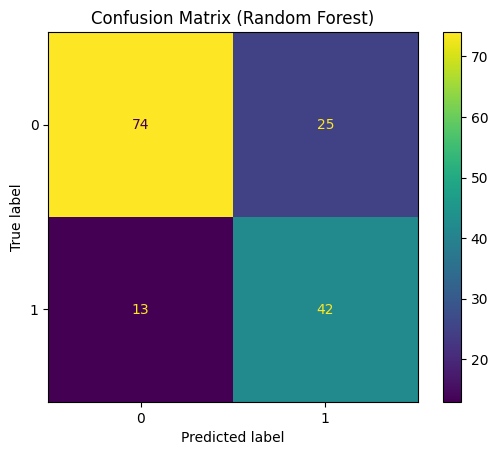

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Initialize the Random Forest model
model_rf = RandomForestClassifier(random_state=42)

# Train the model on the SMOTE-resampled training data
model_rf.fit(X_train_resampled, y_train_resampled)

# Make predictions on the scaled testing data using the new model
y_pred_rf = model_rf.predict(X_test_scaled)

# Display the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=model_rf.classes_)
disp_rf.plot()
plt.title('Confusion Matrix (Random Forest)')
plt.show()

In [35]:
from sklearn.metrics import classification_report

print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_resampled))

print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_tree))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.82      0.70      0.75        99
           1       0.57      0.73      0.64        55

    accuracy                           0.71       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.71      0.71       154


Classification Report (Decision Tree):


NameError: name 'y_pred_tree' is not defined

In [ ]:
from sklearn.svm import LinearSVC

# Initialize the Linear SVM model
model_svm = LinearSVC(random_state=42, dual=False)

# Train the model on the SMOTE-resampled training data
model_svm.fit(X_train_resampled, y_train_resampled)

# Make predictions on the scaled testing data using the new model
y_pred_svm = model_svm.predict(X_test_scaled)

# Display the classification report
print("Classification Report (Linear SVM):")
print(classification_report(y_test, y_pred_svm))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Initialize the KNN model
model_knn = KNeighborsClassifier()

# Train the model on the SMOTE-resampled training data
model_knn.fit(X_train_resampled, y_train_resampled)

# Make predictions on the scaled testing data using the new model
y_pred_knn = model_knn.predict(X_test_scaled)

# Display the classification report
print("Classification Report (KNN):")
print(classification_report(y_test, y_pred_knn))

Classification Report (KNN with k=3):
              precision    recall  f1-score   support

           0       0.80      0.70      0.75        99
           1       0.56      0.69      0.62        55

    accuracy                           0.69       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.72      0.69      0.70       154

Classification Report (KNN with k=5):
              precision    recall  f1-score   support

           0       0.79      0.67      0.72        99
           1       0.53      0.67      0.59        55

    accuracy                           0.67       154
   macro avg       0.66      0.67      0.66       154
weighted avg       0.69      0.67      0.68       154

Classification Report (KNN with k=6):
              precision    recall  f1-score   support

           0       0.78      0.73      0.75        99
           1       0.56      0.64      0.60        55

    accuracy                           0.69       154
   macro avg  

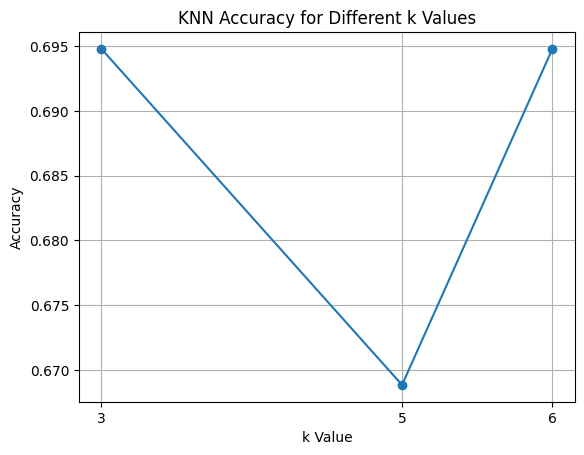

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

k_values = [3, 5, 6]
accuracies = []

for k in k_values:
    # Initialize the KNN model with the current k value
    model_knn = KNeighborsClassifier(n_neighbors=k)

    # Train the model on the SMOTE-resampled training data
    model_knn.fit(X_train_resampled, y_train_resampled)

    # Make predictions on the scaled testing data using the new model
    y_pred_knn = model_knn.predict(X_test_scaled)

    # Display the classification report
    print(f"Classification Report (KNN with k={k}):")
    print(classification_report(y_test, y_pred_knn))

    # Calculate and store the accuracy
    accuracy = accuracy_score(y_test, y_pred_knn)
    accuracies.append(accuracy)

# Plot the accuracy for each k value
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k Value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different k Values')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [38]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# Gaussian Naive Bayes
model_gnb = GaussianNB()
model_gnb.fit(X_train_resampled, y_train_resampled)
y_pred_gnb = model_gnb.predict(X_test_scaled)
print("\nClassification Report (Gaussian Naive Bayes):")
print(classification_report(y_test, y_pred_gnb))


Classification Report (Gaussian Naive Bayes):
              precision    recall  f1-score   support

           0       0.83      0.72      0.77        99
           1       0.59      0.73      0.65        55

    accuracy                           0.72       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154

